# Entitiy Resolution PoC

Dieser PoC beschäftigt sich mit Entity Resolution (ER) mit Matryoshka Embeddings von `jina-embeddings-v4` und Hierarchical Navigable Small World (HNSW) für die ANN Suche als zu grunde liegende Technologien.

Jina AI verwendet in ihren Modellen das Matryoshka Prinzip nach Kusupati et al. (2022). Hierbei werden verschiedene "Dimensionsstufen" in die Loss-Funktion eines Modells eingearbeitet:
$$
\mathcal{L}_{MRL}=∑_{m∈\mathcal{M}}c_m⋅\mathcal{L} ⁣(f^{(m)}(x), y)
$$

| Symbol | Bedeutung |
|--------|-----------|
| $\mathcal{M}$ | Menge der Nested-Dimensionen, z.B. $\{128, 256, 512, 1024, 2048\}$ |
| $m$ | Eine konkrete Dimension $m \in \mathcal{M}$ |
| $c_m$ | Gewicht für Dimension $m$ (oft $c_m = 1 \ \forall m$) |
| $f^{(m)}(x)$ | Erste $m$ Dimensionen des vollen Embeddings $f(x) \in \mathbb{R}^d$ |
| $\mathcal{L}$ | Basis-Loss (z.B. InfoNCE / Contrastive Loss) |

## Setup

In [1]:
import time
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from helper import setup_environment, setup_device, make_faiss_index, print_environment_info


in_kaggle = setup_environment()
DEVICE = setup_device()
print_environment_info(in_kaggle, DEVICE)

Installiere transformers==4.57.6...
Python:       /Users/finnhertsch/projects/entity-res/.venv/bin/python
transformers: 4.57.6
Environment : Local
Device      : mps


## Synthetische Datenerstellung

In [2]:
from DataProvider import SAPMasterDataGenerator
from IPython.display import display

generator = SAPMasterDataGenerator(42)

def generate_data(n):
    
    df_base = generator.generate_base_data(n=n)
    df_noisy = generator.generate_noisy_duplicates(df_base)
    print(f"Generated: {len(df_base)} originals, {len(df_noisy)} noisy duplicates.")
    return df_base, df_noisy


def highlight_differences(df_base, df_noisy, n_samples=10):
    base_sample = df_base.head(n_samples).reset_index(drop=True)
    noisy_sample = df_noisy.head(n_samples).reset_index(drop=True)

    shared_cols = [c for c in base_sample.columns if c in noisy_sample.columns]
    diff_mask = base_sample[shared_cols] != noisy_sample[shared_cols]

    def style_base(row):
        return ["background-color: #d4edda; color: #155724"] * len(row)

    def style_noisy(data):
        styles = pd.DataFrame("", index=data.index, columns=data.columns)
        for col in diff_mask.columns:
            if col in data.columns:
                styles.loc[diff_mask[col], col] = "background-color: #f8d7da; color: #721c24; font-weight: bold"
        return styles

    styled_base = (
        base_sample[shared_cols]
        .style.apply(style_base, axis=1)
        .set_caption("Base Records")
        .set_table_styles([{"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]}])
    )

    styled_noisy = (
        noisy_sample[shared_cols]
        .style.apply(style_noisy, axis=None)
        .set_caption("Noisy Duplicates  (red = changed field)")
        .set_table_styles([{"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]}])
    )

    display(styled_base)
    display(styled_noisy)
    return diff_mask


def show_diff_summary(diff_mask):
    summary = diff_mask.sum().rename("Changed Fields").to_frame()
    summary["Change Rate"] = (diff_mask.mean() * 100).round(1).astype(str) + "%"
    summary = summary[summary["Changed Fields"] > 0].sort_values("Changed Fields", ascending=False)

    display(
        summary.style
        .background_gradient(subset=["Changed Fields"], cmap="Reds")
        .set_caption("📊 Diff Summary (first 10 pairs)")
    )


def show_side_by_side_pair(df_base, df_noisy, idx=0):
    shared_cols = [c for c in df_base.columns if c in df_noisy.columns]
    row_base = df_base.iloc[idx][shared_cols]
    row_noisy = df_noisy.iloc[idx][shared_cols]

    comparison = pd.DataFrame({"Base": row_base, "Noisy": row_noisy})
    comparison["Changed"] = comparison["Base"] != comparison["Noisy"]

    display(
        comparison.style
        .apply(lambda row: [
            "", "",
            "color: red; font-weight: bold" if row["Changed"] else "color: green"
        ], axis=1)
        .set_caption(f"Record pair at index {idx}")
    )


df_syn_base, df_syn_noisy = generate_data(n=1_000)
diff_mask = highlight_differences(df_syn_base, df_syn_noisy, n_samples=10)
show_diff_summary(diff_mask)
show_side_by_side_pair(df_syn_base, df_syn_noisy, idx=0)

Generated: 1000 originals, 1000 noisy duplicates.


,text
0,"Dowerg | Henschelplatz 218, Backnang | Industrie-Zentrifuge"
1,"Davids AG & Co. OHG | Camilla-Gumprich-Allee 4-8, Altötting | OsciJet Fluidik-Oszillator"
2,"Thanel GmbH & Co. KG | Försterplatz 71/21, Ilmenau | OsciJet Fluidik-Oszillator"
3,"Hettner | Reisinggasse 2-9, Sebnitz | Industrie-Zentrifuge"
4,"Klotz | Bartholomäus-Speer-Platz 2/4, Konstanz | Laborabzug Pro X"
5,"Metz Schuster GmbH | Klappplatz 2/3, Eberswalde | Abfüllanlage Type 3"
6,"Kramer Hiller KGaA | Wilmsenallee 3, Herford | Abfüllanlage Type 3"
7,"Heuser Bolzmann AG & Co. OHG | Gerdi-Ortmann-Straße 32-44, Wolfratshausen | Abfüllanlage Type 3"
8,"Lorch | Hartmannplatz 21-30, Tecklenburg | Industrie-Zentrifuge"
9,"Schenk Bolnbach GmbH | Rädelring 1, Sondershausen | OsciJet Fluidik-Oszillator"


,text
0,"Dowerg | Henschelplatz 28, Backnanng"
1,"Davids AG&Co.OHG | Camilla-Gumprich-al. 8-4, Altötting | oSCIjET fLUIDIK-oSZILLATOR"
2,"Thanel Ges.m.b.H & Co. KG | FörsterPl. 17/21, Ilmenau | OsciJet Fluidik-Oszillator"
3,"Hetnner | Reisinggasse 2-9, Sebnitz | Industrie-Zentrifuge"
4,Kolzt | Laborabzug Pro X
5,Metz Schuster GmbH | Abfüllanlage Type 3
6,"Wilmsenallee 3, Herford | Abfüllange Type 3"
7,Heuser Bolzmann AG & Co. OHG | Abfüllanlage Tyype3
8,"Lorch | HartmannPl. 20-31, Tecklenburg | iNDUSTRIE-zENTRIFUGE"
9,"Schenk Bolnbach Gesellschaft mbH | Rädelrng. 1, Sondershausen | oSCIjET fLUIDIK-oSZILLATOR"


,Changed Fields,Change Rate
text,10,100.0%


,Base,Noisy,Changed
text,"Dowerg | Henschelplatz 218, Backnang | Industrie-Zentrifuge","Dowerg | Henschelplatz 28, Backnanng",True


### Load Real Datasets

In [3]:
import os

data_path = "data/AmazonGoogleProducts"

df_amazon = pd.read_csv(os.path.join(data_path, "Amazon.csv"), encoding='latin1')
df_google = pd.read_csv(os.path.join(data_path, "GoogleProducts.csv"), encoding='latin1')
df_mapping = pd.read_csv(os.path.join(data_path, "Amzon_GoogleProducts_perfectMapping.csv"), encoding='latin1')

print(f"Amazon: {len(df_amazon)} Records")
print(f"Google: {len(df_google)} Records")
print(f"Echte Dubletten im Mapping: {len(df_mapping)}")

Amazon: 1363 Records
Google: 3226 Records
Echte Dubletten im Mapping: 1300


In [4]:
def prepare_amazon_google(df, source_type):
    df = df.fillna("")
    if source_type == "amazon":
        df['text'] = df['title'] + " " + df['description'] + " " + df['manufacturer']
    else:
        df['text'] = df['name'] + " " + df['description'] + " " + df['manufacturer']
    
    df['text'] = df['text'].str.lower().str.replace(r'[^a-z0-9 ]', '', regex=True)
    df['text'] = df['text'].str.slice(0, 512)
    return df[['id', 'text']]

df_amazon_clean = prepare_amazon_google(df_amazon, "amazon")
df_google_clean = prepare_amazon_google(df_google, "google")

In [5]:
if df_amazon_clean.index.name != 'id':
    df_amazon_clean = df_amazon_clean.set_index('id')

reverse_mapping = dict(zip(df_mapping['idGoogleBase'], df_mapping['idAmazon']))

df_google_clean['ground_truth_id'] = df_google_clean['id'].map(reverse_mapping)

matches_only = df_google_clean[df_google_clean['ground_truth_id'].notna()].copy()

sample_ids_google = matches_only.head(10).index
sample_ids_amazon = matches_only.head(10)['ground_truth_id']

df_a_viz = df_amazon_clean.loc[sample_ids_amazon].reset_index()[['text']]
df_g_viz = matches_only.loc[sample_ids_google].reset_index()[['text']]

print("Daten sind für den Real-World-Check vorbereitet!")

Daten sind für den Real-World-Check vorbereitet!


In [6]:
diff_mask_real = highlight_differences(df_a_viz, df_g_viz, n_samples=10)

show_diff_summary(diff_mask_real)
show_side_by_side_pair(df_a_viz, df_g_viz, idx=2)

,text
0,learning quickbooks 2007 designed for new quickbooks users running either quickbooks pro 2007 or quickbooks premier 2007 all versions learning quickbooks for windows takes you stepbystep through the essentials of mastering quickbooks basics highly qualified instructors teach you key tasks using reallife examples now you can get an introduction to bookkeeping fundamentalswithout all the technical jargonand gain the confidence of knowing youre doing it right features include an overview of bookkeeping basics
1,quickbooks pointofsale basic 60 quickbooks pointofsale basic 60 retail management software turns any pc into a cash register that does what no ordinary cash register can do it automatically tracks your inventory and customers while you ring up sales its a highpowered retailmanagement system that tracks inventory sales and customer information to help save you time and better serve your customers track inventory automatically as you ring up sales view larger see each customers purchase history as you ring up
2,adobe creative suite cs3 production premium upgrade note this is the upgrade version of adobe creative suite 3 production premium maximize your productivity with adobe creative suite 3 production premium upgrade software the total postproduction solution available for both mac and windows tighterthanever integration between adobes allnew video audio and design toolsnow including adobe flash cs3 professional softwareoffers a smooth workflow from concept to delivery reach the widest possible audience by deliv
3,ulead videostudio 11 plus ulead videostudio 11 plus is a complete endtoend hd dvd solution and video editing and dvd authoring software for anyone who wants to easily produce professionallooking videos slide shows and dvds this editing software lets you capture video from the latest hd camcorders and create amazing highdefinition dvds with timesaving templatebased wizards and powerful handson tools it will let you express your creativity without the hassle of confusing software interfaces or processes find
4,quickbooks pos pro multistore 60 quickbooks pointofsale pro multistore 60 retailmanagement software turns any pc into a cash register that does what no ordinary cash register can do it automatically keeps track of your detailed inventory customers sales orders layaways and employee commissions and tips while you and your employees are ringing up sales in up to 10 different locations its a highpowered retailmanagement system that tracks inventory sales and customer information to help save you time and bette
5,quickbooks credit card processing kit 30 quickbooks credit card processing kit is the lowcost easy way to accept all major credit cards using your computer its a lowcost solution without longterm contracts or commitments start accepting credit cards easily and inexpensively there are no setup fees no monthly minimum payments no terminals to lease or purchase and no longterm contracts accept payments any time anywhere process transactions from a pc with an internet connection or call for a voice authorizatio
6,vegas movie studiodvd8 plat becoming a movie mogul or star is easy with sony vegas movie studio distributing your video creation to friends families and producers is even better with sony dvd8 vegas movie studiodvd platinum software offers everything you get with the standard version such as easy draganddrop video editing integrated dvd layout and burning and show me how interactive tutorials in addition platinum edition provides added features advanced editing tools bonus video effects and a comprehensive
7,quickbooks pointofsale pro with hardware bundle 60 the quickbooks pointofsale pro 60 retailmanagement softwarehardware bundle turns any pc into a cash register that does what no ordinary cash register can do it automatically keeps track of your detailed inventory customers sales orders layaways and employee commissions and tips while you ring up sales this guaranteedcompatible softwareha

,text
0,learning quickbooks 2007 learning quickbooks 2007 intuit
1,qb pos 60 basic software qb pos 60 basic retail mngmt software for retailers who need basic inventory sales and customer tracking intuit
2,production prem cs3 mac upgrad adobe cs3 production premium mac upgrade from production studio premium or standard adobe software
3,video studio 11 plus corel video studio 11 plus is consumer video editing and dvd authoring software that lets anyone do more with video corel corporation
4,qb pos 60 pro multi store sw qb pos 60 pro multistore retail mngmt software has all the features in basic plus the ability to manage up to ten stores from a single office intuit
5,qb credit card kit 30 quickbooks credit card kit v30 2007 intuit
6,vegas movie studiodvd8 plat sony media software vegas movie studio dvd 8 platinum edition video editing and dvd creation software vegas movie studio platinum edition software provides the power features and advanced tools you need to edit video in nearly any format sony creative software
7,qb pos 60 pro solution hwsw qb pos 60 pro solution hwsw ships in an unprinted corrugated shipper intuit
8,evergirl pc cdrom video game based on the tween lifestyle brand launched in 2004 this actionadventure game will contain loads of adventures tailored specifically to the players personality type the evergirl brand features a clothing and accessories line with a companion web
9,902453007b rumba unixhp edition upgrade license 1 user volume level b 549 c netmanage 902453007b usually ships in 24 hours the rumba product family provides users secure access to missioncritical applications and data residing on virtually any host system from the latest windows desktops including windows xp and


,Changed Fields,Change Rate
text,10,100.0%


,Base,Noisy,Changed
text,adobe creative suite cs3 production premium upgrade note this is the upgrade version of adobe creative suite 3 production premium maximize your productivity with adobe creative suite 3 production premium upgrade software the total postproduction solution available for both mac and windows tighterthanever integration between adobes allnew video audio and design toolsnow including adobe flash cs3 professional softwareoffers a smooth workflow from concept to delivery reach the widest possible audience by deliv,production prem cs3 mac upgrad adobe cs3 production premium mac upgrade from production studio premium or standard adobe software,True


## Erstellung der Embeddings

In [7]:
import hashlib
from pathlib import Path
from tqdm.auto import tqdm
from EmbeddingPipe import pipeline

CACHE_DIR = Path(".embedding_cache")
CACHE_DIR.mkdir(exist_ok=True)

OPTIMAL_BATCH_SIZE = {
    "cuda": 512,
    "mps":  256,
    "cpu":  64,
}

def _cache_key(texts: list[str], dtype: str) -> str:
    content = "".join(texts) + dtype
    return hashlib.md5(content.encode()).hexdigest()


def encode_with_cache(texts: list[str], label: str, dtype=np.float16) -> np.ndarray:
    key = _cache_key(texts, dtype.__name__)
    cache_file = CACHE_DIR / f"{label}_{key}.npy"

    if cache_file.exists():
        print(f"[{label}] Loading from cache...", end=" ")
        result = np.load(cache_file)
        print("done.")
        return result

    batch_size = OPTIMAL_BATCH_SIZE.get(DEVICE.type, 256)
    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc=f"[{label}]", leave=False):
        batch = texts[i : i + batch_size]
        emb = pipeline.encode(batch, batch_size=len(batch))
        all_embeddings.append(emb.astype(dtype))

    result = np.vstack(all_embeddings)
    np.save(cache_file, result)
    print(f"[{label}] Cached → {cache_file}")
    return result


def encode_parallel(df_base, df_noisy) -> tuple[np.ndarray, np.ndarray]:
    base_emb  = encode_with_cache(df_base["text"].tolist(),  "base")
    noisy_emb = encode_with_cache(df_noisy["text"].tolist(), "noisy")
    return base_emb, noisy_emb


def print_embedding_stats(base_emb, noisy_emb):
    for label, emb in [("Base", base_emb), ("Noisy", noisy_emb)]:
        print(f"{label:6s} | shape: {emb.shape} | dtype: {emb.dtype} | {emb.nbytes / 1_000_000:.1f} MB")


print("--- Generiere Embeddings: Synthetisch ---")
syn_base_emb, syn_noisy_emb = encode_parallel(df_syn_base, df_syn_noisy)
print_embedding_stats(syn_base_emb, syn_noisy_emb)

print("\n--- Generiere Embeddings: Amazon-Google ---")
real_base_emb, real_noisy_emb = encode_parallel(df_amazon_clean, df_google_clean)
print_embedding_stats(real_base_emb, real_noisy_emb)

Lade Modell 'jinaai/jina-embeddings-v4'...


`torch_dtype` is deprecated! Use `dtype` instead!


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Modell geladen auf mps.
--- Generiere Embeddings: Synthetisch ---
[base] Loading from cache... done.
[noisy] Loading from cache... done.
Base   | shape: (1000, 2048) | dtype: float16 | 4.1 MB
Noisy  | shape: (1000, 2048) | dtype: float16 | 4.1 MB

--- Generiere Embeddings: Amazon-Google ---
[base] Loading from cache... done.
[noisy] Loading from cache... done.
Base   | shape: (1363, 2048) | dtype: float16 | 5.6 MB
Noisy  | shape: (3226, 2048) | dtype: float16 | 13.2 MB


## Indizierung & Evaluation

In [8]:
from EmbeddingPipe import truncate_and_normalize

K = 50
N_RUNS = 100

def _measure_latency(index, noisy_emb: np.ndarray, n_runs: int) -> float:
    times = []
    for _ in range(n_runs):
        start = time.perf_counter()
        index.search(noisy_emb, K)
        times.append((time.perf_counter() - start) * 1000 / len(noisy_emb))
    return float(np.median(times))

def evaluate_dimension(dim, index, base_emb_full, noisy_emb_full, ground_truth_ids, df_base) -> dict:
    print(f"Evaluating dimension: {dim}")

    base_emb = truncate_and_normalize(base_emb_full, dim).astype(np.float32)
    noisy_emb = truncate_and_normalize(noisy_emb_full, dim).astype(np.float32)

    index.add(base_emb)
    latency_ms = _measure_latency(index, noisy_emb, N_RUNS)
    _, indices = index.search(noisy_emb, K)

    recall_at_1 = []
    recall_at_50 = []
    
    valid_pair_sims_full = []
    valid_pair_sims_trunc = []

    base_full_norm = truncate_and_normalize(base_emb_full, 2048).astype(np.float32)
    noisy_full_norm = truncate_and_normalize(noisy_emb_full, 2048).astype(np.float32)

    for i, gt_id in enumerate(ground_truth_ids):
        if gt_id in df_base.index:
            gt_pos = df_base.index.get_loc(gt_id)
            
            recall_at_1.append(indices[i][0] == gt_pos)
            recall_at_50.append(gt_pos in indices[i])
            
            sim_full = np.dot(noisy_full_norm[i], base_full_norm[gt_pos])
            valid_pair_sims_full.append(sim_full)
            sim_trunc = np.dot(noisy_emb[i], base_emb[gt_pos])
            valid_pair_sims_trunc.append(sim_trunc)

    info_retention, _ = pearsonr(valid_pair_sims_full, valid_pair_sims_trunc)

    return {
        "Dimension": dim,
        "Recall@1": np.mean(recall_at_1),
        "Recall@50": np.mean(recall_at_50),
        "Latency (ms)": round(latency_ms, 4),
        "Info Retention (Corr)": round(float(info_retention), 6),
    }

In [9]:
def run_full_evaluation(label, base_emb, noisy_emb, df_base, df_noisy, ground_truth_col=None):
    print(f"\n=== Evaluation: {label} ===")
    
    if ground_truth_col:
        gt_ids = df_noisy[ground_truth_col].tolist()
    else:
        gt_ids = df_base.index.tolist() 

    dims = [128, 512, 2048]
    results = []

    for d in dims:
        idx = make_faiss_index(d, DEVICE)
        
        res = evaluate_dimension(
            dim=d,
            index=idx,
            base_emb_full=base_emb,
            noisy_emb_full=noisy_emb,
            ground_truth_ids=gt_ids,
            df_base=df_base
        )
        results.append(res)
    
    return pd.DataFrame(results)

In [10]:
# --- 1. Synthetische Daten ---
results_syn = run_full_evaluation(
    "Synthetisch (SAP)", 
    syn_base_emb, 
    syn_noisy_emb, 
    df_syn_base, 
    df_syn_noisy
)

# --- 2. Real-World Daten ---
results_real = run_full_evaluation(
    "Amazon-Google", 
    real_base_emb, 
    real_noisy_emb, 
    df_amazon_clean, 
    df_google_clean,
    ground_truth_col='ground_truth_id'
)


print("\n--- SYNTHETISCH ---")
print(results_syn.to_string(index=False))

print("\n--- REAL-WORLD ---")
print(results_real.to_string(index=False))


=== Evaluation: Synthetisch (SAP) ===
Evaluating dimension: 128
Evaluating dimension: 512
Evaluating dimension: 2048

=== Evaluation: Amazon-Google ===
Evaluating dimension: 128
Evaluating dimension: 512
Evaluating dimension: 2048

--- SYNTHETISCH ---
 Dimension  Recall@1  Recall@50  Latency (ms)  Info Retention (Corr)
       128     0.925      0.991        0.0179               0.983692
       512     0.947      0.992        0.0270               0.994062
      2048     0.960      0.996        0.0631               1.000000

--- REAL-WORLD ---
 Dimension  Recall@1  Recall@50  Latency (ms)  Info Retention (Corr)
       128  0.575523   0.939582        0.0199               0.959834
       512  0.652982   0.972115        0.0306               0.987513
      2048  0.678544   0.971340        0.0706               1.000000


## Visualisierung & Reporting

In [11]:
def plot_results(results_df):
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

    dims = results_df["Dimension"].astype(str)
    x = np.arange(len(dims))

    ax1.plot(results_df["Dimension"], results_df["Info Retention (Corr)"],
             marker='o', color='steelblue', linewidth=2)
    ax1.set_xscale('log')
    ax1.set_xticks(results_df["Dimension"])
    ax1.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax1.set_title("Info Retention")
    ax1.set_xlabel("Dimension")
    ax1.set_ylabel("Correlation with 2048d")
    ax1.set_ylim(0.95, 1.01)

    ax2.bar(x, results_df["Recall@1"], color='#2ca02c', alpha=0.85, label='Recall@1')
    ax2.bar(x, results_df["Recall@50"], color="#0b3802", alpha=0.5, label='Recall@50')
    ax2.set_xticks(x)
    ax2.set_xticklabels(dims)
    ax2.set_title("Recall")
    ax2.set_xlabel("Dimension")
    ax2.set_ylabel("Score")
    ax2.set_ylim(0, 1.15)
    ax2.legend()

    ax3.bar(x, results_df["Latency (ms)"], color='#d62728', alpha=0.85)
    ax3.set_xticks(x)
    ax3.set_xticklabels(dims)
    ax3.set_title("Search Latency")
    ax3.set_xlabel("Dimension")
    ax3.set_ylabel("ms / query")

    plt.suptitle("Dimension Evaluation", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## Ausführung

VISUALISIERUNG: SYNTHETISCHE SAP-DATEN


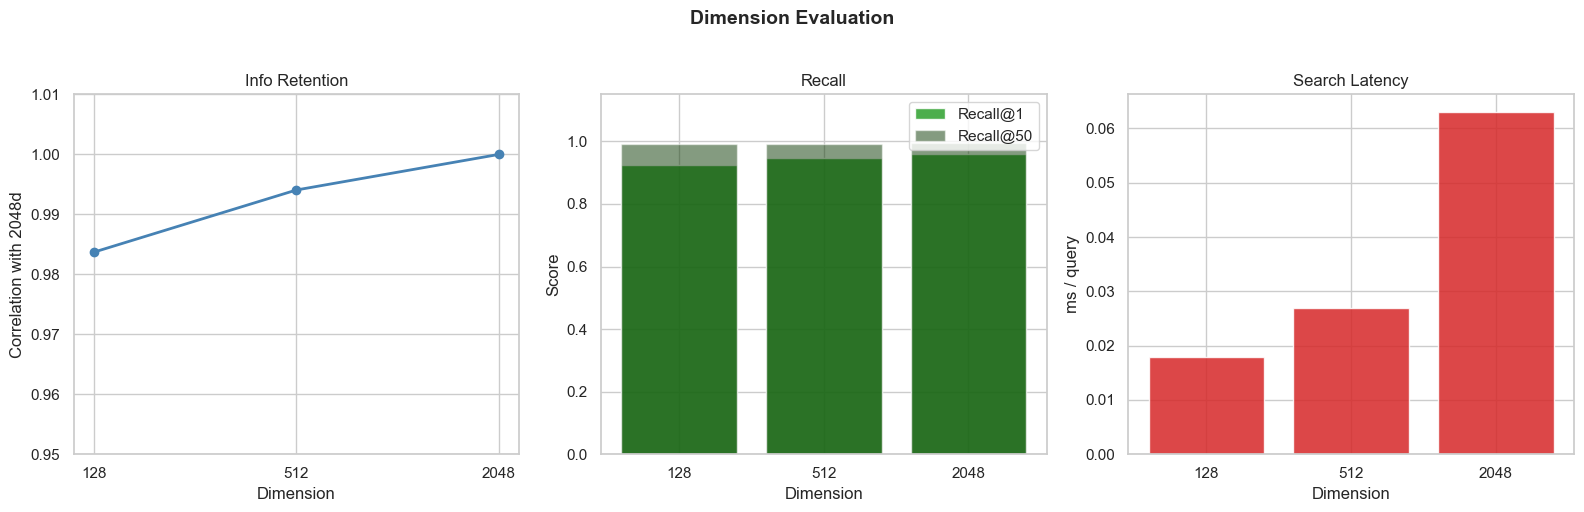



VISUALISIERUNG: REAL-WORLD (AMAZON-GOOGLE)


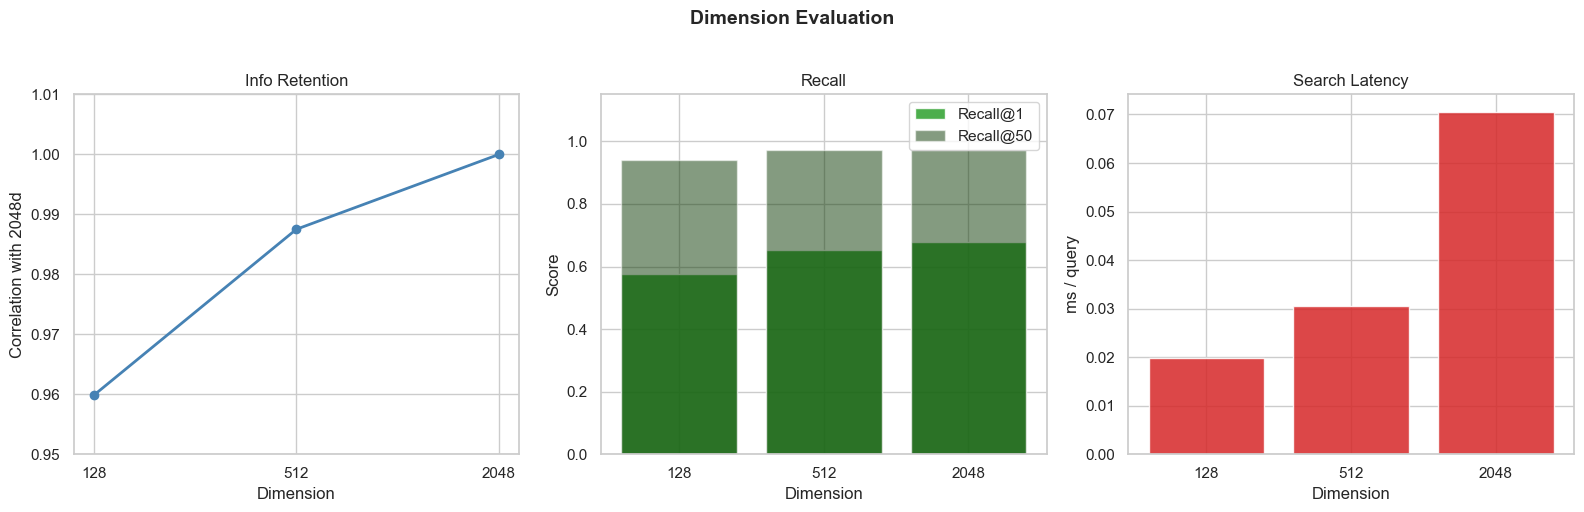

In [12]:
print("VISUALISIERUNG: SYNTHETISCHE SAP-DATEN")
plot_results(results_syn)

print("\n" + "="*50 + "\n")

print("VISUALISIERUNG: REAL-WORLD (AMAZON-GOOGLE)")
plot_results(results_real)

## Vorbereitung für die Entity Resolution

In [13]:
def get_candidates_for_noisy_data(base_embeddings, noisy_embeddings, k=5):
    idx = make_faiss_index(2048, DEVICE)
    idx.add(base_embeddings.astype(np.float32))
    distances, indices = idx.search(noisy_embeddings.astype(np.float32), k=k)
    return distances, indices

def generate_candidate_data(df_noisy, df_base, distances, indices):
    pairs = []
    scores = []
    
    for i in range(len(indices)):
        for j, neighbor_idx in enumerate(indices[i]):
            pairs.append((df_noisy.iloc[i], df_base.iloc[neighbor_idx]))
            scores.append(distances[i][j])
            
    return pairs, scores

print("Erstelle Kandidaten für Synthetisch...")
D_syn, I_syn = get_candidates_for_noisy_data(syn_base_emb, syn_noisy_emb, k=5)
candidate_pairs_syn, candidate_scores_syn = generate_candidate_data(df_syn_noisy, df_syn_base, D_syn, I_syn)

print("Erstelle Kandidaten für Amazon-Google...")
D_real, I_real = get_candidates_for_noisy_data(real_base_emb, real_noisy_emb, k=5)
candidate_pairs_real, candidate_scores_real = generate_candidate_data(df_google_clean, df_amazon_clean, D_real, I_real)

print(f"\nVorbereitung abgeschlossen.")
print(f"Synthetische Paare: {len(candidate_pairs_syn)}")
print(f"Real-World Paare:    {len(candidate_pairs_real)}")

Erstelle Kandidaten für Synthetisch...
Erstelle Kandidaten für Amazon-Google...

Vorbereitung abgeschlossen.
Synthetische Paare: 5000
Real-World Paare:    16130


## Feature Engineering

In [14]:
import re
import numpy as np
from rapidfuzz import fuzz
from rapidfuzz.distance import JaroWinkler

def clean_text(text):
    text = str(text).lower()
    noise = ['software', 'windows', 'win', 'macintosh', 'mac', 'version', 'v', 
             'complete', 'product', 'full', 'professional', 'pro', 'edition',
             'jewel', 'case', 'system', 'requirements', 'download', 'dvd', 'cd']
    for word in noise:
        text = text.replace(f" {word} ", " ")
    replacements = {'qb': 'quickbooks', 'pos': 'pointofsale'}
    for k, v in replacements.items():
        text = text.replace(k, v)
    return " ".join(text.split())

def extract_nums(text):
    nums = re.findall(r'\d+', text)
    return set([n[0] if n.endswith('0') and len(n) == 2 else n for n in nums])

def get_enhanced_feature_vector(pair, distance_score):
    row_noisy, row_base = pair
    t1_raw, t2_raw = str(row_noisy['text']).lower(), str(row_base['text']).lower()
    t1, t2 = clean_text(t1_raw), clean_text(t2_raw)

    nums1, nums2 = extract_nums(t1_raw), extract_nums(t2_raw)
    num_match = len(nums1 & nums2) / len(nums1 | nums2) if nums1 | nums2 else 1.0

    vetos = ['mac', 'windows', 'pc', 'dvd', 'upgrade', 'full', 'oem', 'retail']
    veto_conflicts = sum(1 for v in vetos if (v in t1_raw) != (v in t2_raw))

    brand1 = t1.split()[0] if t1.split() else ""
    brand2 = t2.split()[0] if t2.split() else ""
    brand_match = 1.0 if (brand1 == brand2 and brand1 != "") else 0.0

    def get_3grams(text):
        return set(text[i:i+3] for i in range(len(text) - 2))
    g1, g2 = get_3grams(t1), get_3grams(t2)
    ngram_sim = len(g1 & g2) / len(g1 | g2) if (g1 | g2) else 0

    return [
        fuzz.token_set_ratio(t1, t2) / 100.0,
        fuzz.partial_ratio(t1, t2) / 100.0,
        JaroWinkler.similarity(t1, t2),
        ngram_sim,
        distance_score,
        num_match,
        veto_conflicts,
        brand_match
    ]

def extract_features_and_labels(pairs, scores, dataset_type="real"):
    X, y = [], []
    for i, (row_noisy, row_base) in enumerate(pairs):
        f_vec = get_enhanced_feature_vector((row_noisy, row_base), scores[i])
        X.append(f_vec)
        is_match = 1 if (row_noisy['ground_truth_id'] == row_base.name if dataset_type == "real" else row_noisy.name == row_base.name) else 0
        y.append(is_match)
    return np.array(X), np.array(y)

print("Extracting enhanced features (v2.0)...")
X_syn, y_syn = extract_features_and_labels(candidate_pairs_syn, candidate_scores_syn, dataset_type="syn")
X_real, y_real = extract_features_and_labels(candidate_pairs_real, candidate_scores_real, dataset_type="real")

Extracting enhanced features (v2.0)...


## XGBoost Clf


--- ⚡ XGBoost Training & Zero-FP Analysis: Synthetisch ---
Mean F1-Score (CV): 0.9766
Zero-FP Threshold gefunden: 0.9470

Absolutes Ergebnis (Threshold 0.9470):
False Positives (FP): 0
True Positives (TP):  980
Recall:               1.0000


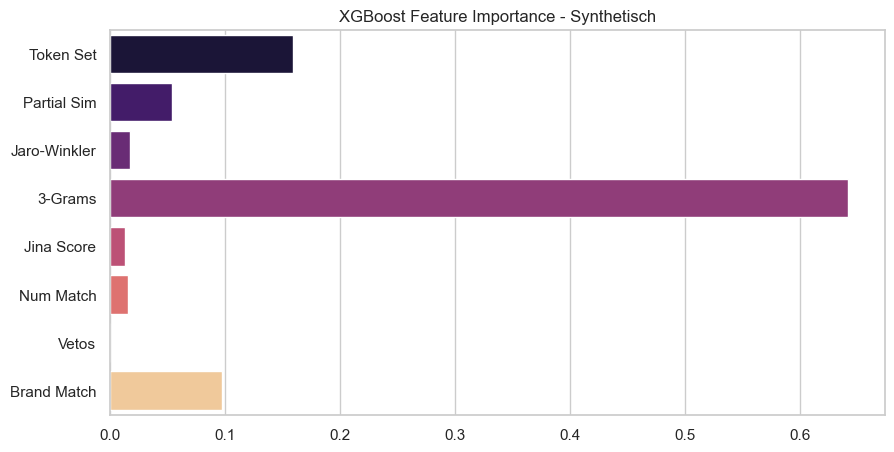


--- ⚡ XGBoost Training & Zero-FP Analysis: Amazon-Google ---
Mean F1-Score (CV): 0.4344
Zero-FP Threshold gefunden: 0.9565

Absolutes Ergebnis (Threshold 0.9565):
False Positives (FP): 0
True Positives (TP):  1146
Recall:               0.9922


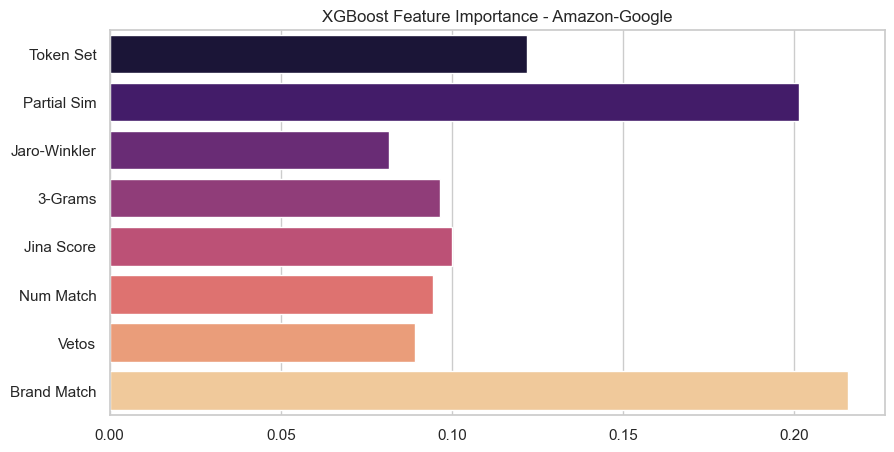

In [15]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, precision_recall_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def train_and_analyze_xgb(X, y, label="Dataset"):
    print(f"\n--- ⚡ XGBoost Training & Zero-FP Analysis: {label} ---")
    
    ratio = np.sum(y==0) / np.sum(y==1)
    
    model = xgb.XGBClassifier(
        n_estimators=946,
        max_depth=8,
        learning_rate=0.12596946471623574,
        subsample=0.6348149573126103,
        colsample_bytree=0.8146767157484014,
        min_child_weight=3,
        scale_pos_weight=16.023283131651812,
        random_state=42,
        eval_metric='logloss'
    )
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, scoring='f1')
    print(f"Mean F1-Score (CV): {np.mean(scores):.4f}")
    
    model.fit(X, y)
    probs = model.predict_proba(X)[:, 1]
    
    precision, recall, thresholds = precision_recall_curve(y, probs)
    
    zero_fp_mask = precision == 1.0
    if any(zero_fp_mask):
        idx = np.where(zero_fp_mask)[0][0]
        opt_thresh = thresholds[idx] if idx < len(thresholds) else np.max(probs)
        print(f"Zero-FP Threshold gefunden: {opt_thresh:.4f}")
    else:
        opt_thresh = np.max(probs)
        print(f"Warnung: Kein 0-FP Threshold. Max Probs: {opt_thresh:.4f}")
        
    final_preds = (probs >= opt_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, final_preds).ravel()
    
    print(f"\nAbsolutes Ergebnis (Threshold {opt_thresh:.4f}):")
    print(f"False Positives (FP): {fp}")
    print(f"True Positives (TP):  {tp}")
    print(f"Recall:               {tp/(tp+fn):.4f}")
    
    feature_names = [
        'Token Set',      # fuzz.token_set_ratio
        'Partial Sim',    # fuzz.partial_ratio
        'Jaro-Winkler',   # JaroWinkler.similarity
        '3-Grams',        # ngram_sim
        'Jina Score',     # distance_score
        'Num Match',      # num_match
        'Vetos',          # veto_conflicts
        'Brand Match'     # brand_match (NEU)
    ]
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=model.feature_importances_, y=feature_names, hue=feature_names, palette="magma", legend=False)
    plt.title(f"XGBoost Feature Importance - {label}")
    plt.show()
    
    return model, opt_thresh

model_syn, thresh_syn = train_and_analyze_xgb(X_syn, y_syn, "Synthetisch")
model_real, thresh_real = train_and_analyze_xgb(X_real, y_real, "Amazon-Google")

In [16]:
import os
import optuna
import xgboost as xgb
import numpy as np
from sklearn.metrics import confusion_matrix, precision_recall_curve

# 1. Ordner erstellen
os.makedirs('optuna', exist_ok=True)

def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 25),
        'random_state': 42,
        'eval_metric': 'logloss'
    }

    model = xgb.XGBClassifier(**param)
    model.fit(X_real, y_real)
    probs = model.predict_proba(X_real)[:, 1]

    precision, recall, thresholds = precision_recall_curve(y_real, probs)
    zero_fp_mask = precision == 1.0
    
    if not any(zero_fp_mask):
        return 0.0

    idx = np.where(zero_fp_mask)[0][0]
    opt_thresh = thresholds[idx] if idx < len(thresholds) else np.max(probs)
    
    final_preds = (probs >= opt_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_real, final_preds).ravel()
    
    return tp / (tp + fn)


study_name = "er_zero_fp_optimization"
storage_name = "sqlite:///optuna/er_study.db"

study = optuna.create_study(
    study_name=study_name, 
    storage=storage_name, 
    direction='maximize',
    load_if_exists=True
)

print("Starte Hyperparameter-Optimierung...")
study.optimize(objective, n_trials=100) 

print(f"\nBester Recall bei 0 FP: {study.best_value:.4f}")

[I 2026-04-19 15:24:32,596] Using an existing study with name 'er_zero_fp_optimization' instead of creating a new one.


Starte Hyperparameter-Optimierung...


[I 2026-04-19 15:24:33,398] Trial 100 finished with value: 0.9922077922077922 and parameters: {'n_estimators': 901, 'max_depth': 10, 'learning_rate': 0.13329868658421448, 'subsample': 0.8295062678817533, 'colsample_bytree': 0.8072312629060151, 'min_child_weight': 4, 'scale_pos_weight': 6.4155966705626835}. Best is trial 5 with value: 0.9922077922077922.
[I 2026-04-19 15:24:34,088] Trial 101 finished with value: 0.9922077922077922 and parameters: {'n_estimators': 782, 'max_depth': 11, 'learning_rate': 0.1809363389599888, 'subsample': 0.9020262929629675, 'colsample_bytree': 0.8422599458701769, 'min_child_weight': 3, 'scale_pos_weight': 8.186794493822676}. Best is trial 5 with value: 0.9922077922077922.
[I 2026-04-19 15:24:34,526] Trial 102 finished with value: 0.9922077922077922 and parameters: {'n_estimators': 388, 'max_depth': 11, 'learning_rate': 0.16631554535169782, 'subsample': 0.8547877771377648, 'colsample_bytree': 0.8220973933910547, 'min_child_weight': 2, 'scale_pos_weight': 7.6


Bester Recall bei 0 FP: 0.9922


In [17]:
import optuna.visualization as vis
import plotly

fig1 = vis.plot_optimization_history(study)
fig1.show()

fig2 = vis.plot_param_importances(study)
fig2.show()

fig3 = vis.plot_parallel_coordinate(study)
fig3.show()


--- ⚡ Final XGBoost Training: Synthetisch ---
Mean F1-Score (CV): 0.9775

Absolutes Ergebnis (Threshold 0.8671):
False Positives (FP): 0 🎯
True Positives (TP):  980
Recall:               1.0000


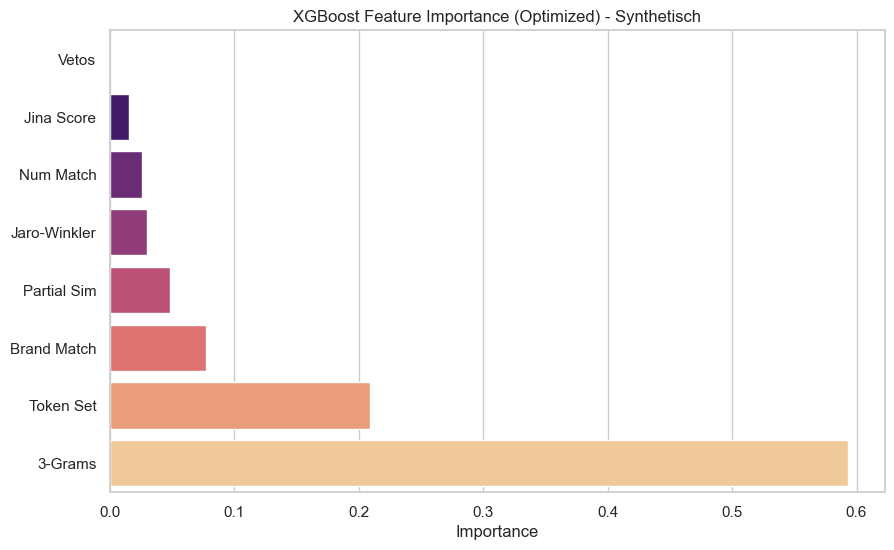


--- ⚡ Final XGBoost Training: Amazon-Google ---
Mean F1-Score (CV): 0.4189

Absolutes Ergebnis (Threshold 0.8995):
False Positives (FP): 0 🎯
True Positives (TP):  1146
Recall:               0.9922


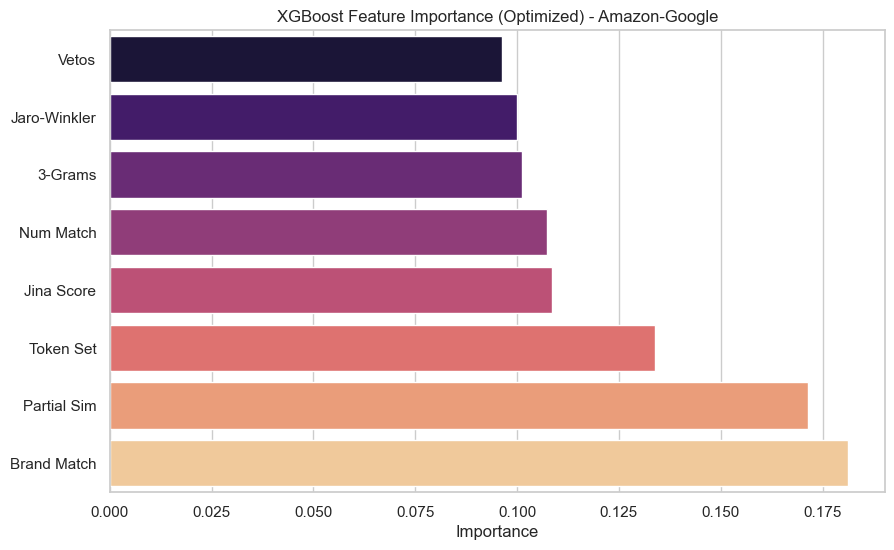


Beste Parameter: {'n_estimators': 908, 'max_depth': 8, 'learning_rate': 0.1331939823509473, 'subsample': 0.5029688981176819, 'colsample_bytree': 0.7774282698358496, 'min_child_weight': 2, 'scale_pos_weight': 5.487552303984584}


In [25]:
def train_and_analyze_xgb_final(X, y, params, label="Dataset"):
    print(f"\n--- ⚡ Final XGBoost Training: {label} ---")
    
    model = xgb.XGBClassifier(**params)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, scoring='f1')
    print(f"Mean F1-Score (CV): {np.mean(scores):.4f}")
    
    model.fit(X, y)
    probs = model.predict_proba(X)[:, 1]
    
    precision, recall, thresholds = precision_recall_curve(y, probs)
    zero_fp_mask = precision == 1.0
    
    idx = np.where(zero_fp_mask)[0][0] if any(zero_fp_mask) else 0
    opt_thresh = thresholds[idx] if idx < len(thresholds) else np.max(probs)
        
    final_preds = (probs >= opt_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, final_preds).ravel()
    
    print(f"\nAbsolutes Ergebnis (Threshold {opt_thresh:.4f}):")
    print(f"False Positives (FP): {fp} 🎯")
    print(f"True Positives (TP):  {tp}")
    print(f"Recall:               {tp/(tp+fn):.4f}")
    
    feature_names = [
        'Token Set', 'Partial Sim', 'Jaro-Winkler', '3-Grams', 
        'Jina Score', 'Num Match', 'Vetos', 'Brand Match', 
        'SKU Match', 'Year Conflict'
    ]
    
    importances = model.feature_importances_
    indices = np.argsort(importances)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances[indices], y=np.array(feature_names)[indices], 
                hue=np.array(feature_names)[indices], palette="magma", legend=False)
    plt.title(f"XGBoost Feature Importance (Optimized) - {label}")
    plt.xlabel("Importance")
    plt.show()
    
    return model, opt_thresh

model_syn, thresh_syn = train_and_analyze_xgb_final(X_syn, y_syn, study.best_params, "Synthetisch")
model_real, thresh_real = train_and_analyze_xgb_final(X_real, y_real, study.best_params, "Amazon-Google")
print(f"\nBeste Parameter: {study.best_params}")


--- Synthetisch (SAP-Stil) ---
Precision: 1.0000 (Wie sicher sind die Treffer?)
Recall:    1.0000 (Wie viele Dubletten wurden gefunden?)
False Positives: 0


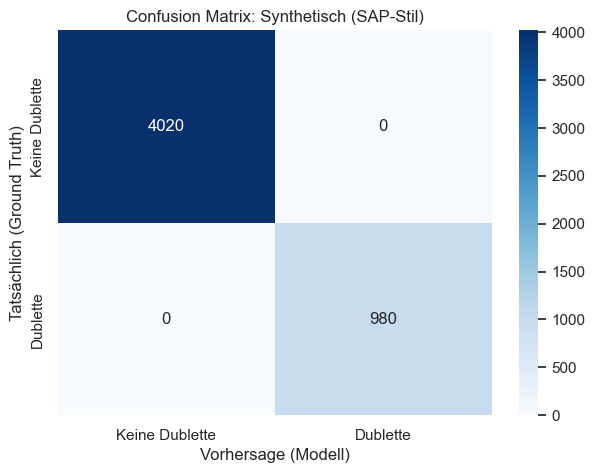


--- Real-World (Amazon-Google) ---
Precision: 1.0000 (Wie sicher sind die Treffer?)
Recall:    0.9922 (Wie viele Dubletten wurden gefunden?)
False Positives: 0


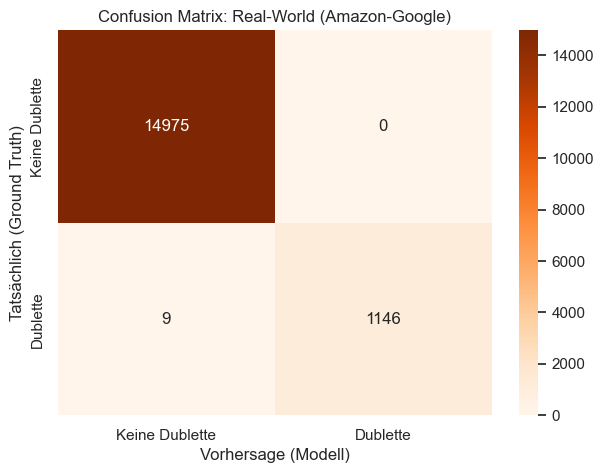

In [26]:
def plot_enhanced_cfm(y_true, y_pred, title, cmap):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, 
                xticklabels=['Keine Dublette', 'Dublette'], 
                yticklabels=['Keine Dublette', 'Dublette'])
    
    plt.xlabel('Vorhersage (Modell)')
    plt.ylabel('Tatsächlich (Ground Truth)')
    plt.title(f'Confusion Matrix: {title}')
    
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"\n--- {title} ---")
    print(f"Precision: {precision:.4f} (Wie sicher sind die Treffer?)")
    print(f"Recall:    {recall:.4f} (Wie viele Dubletten wurden gefunden?)")
    print(f"False Positives: {fp}")
    
    plt.show()

probs_syn = model_syn.predict_proba(X_syn)[:, 1]
preds_syn = (probs_syn >= thresh_syn).astype(int)

probs_real = model_real.predict_proba(X_real)[:, 1]
preds_real = (probs_real >= thresh_real).astype(int)

plot_enhanced_cfm(y_syn, preds_syn, "Synthetisch (SAP-Stil)", "Blues")
plot_enhanced_cfm(y_real, preds_real, "Real-World (Amazon-Google)", "Oranges")

In [27]:
fn_mask = (y_real == 1) & (preds_real == 0)
fn_indices = np.where(fn_mask)[0]

fn_samples = []
for idx in fn_indices:
    row_noisy, row_base = candidate_pairs_real[idx]
    fn_samples.append({
        'Confidence': f"{probs_real[idx]:.4%}",
        'Google': row_noisy['text'],
        'Amazon': row_base['text']
    })

df_fn = pd.DataFrame(fn_samples)
print(f"Analyse der {len(df_fn)} False Negatives:")
display(df_fn)

Analyse der 9 False Negatives:


,Confidence,Google,Amazon
0,86.2478%,encore inc math advantage 2008 math advantage ...,math advantage 2008 math advantage 2008 was sp...
1,81.4787%,nova development corp ideasoft photo clip art ...,ideasoft photo clip art 10 000 stand out from ...
2,86.8957%,magix entertainment corp xtreme photostory on ...,xtreme photostory on cd and dvd 6 magix enter...
3,79.3532%,encore software 11252 brain food games craniu...,brain food games cranium collection 2006 back ...
4,73.2867%,mom standard ops mgmt lic 2005 english mlp 5 o...,mom standard ops mgmt lic 2005 english mlp 5 o...
5,81.3221%,adobe production premium cs3 software suite fo...,adobe creative suite cs3 production premium ma...
6,82.0220%,adobe after effects cs3 professional software ...,adobe after effects cs3 bring your vision to l...
7,78.2365%,adobe production premium cs3 software suite fo...,adobe creative suite cs3 production premium ma...
8,79.5529%,adobe after effects cs3 professional software ...,adobe after effects cs3 bring your vision to l...


## Clustering im Graph

1146 sichere Dubletten-Paare extrahiert.


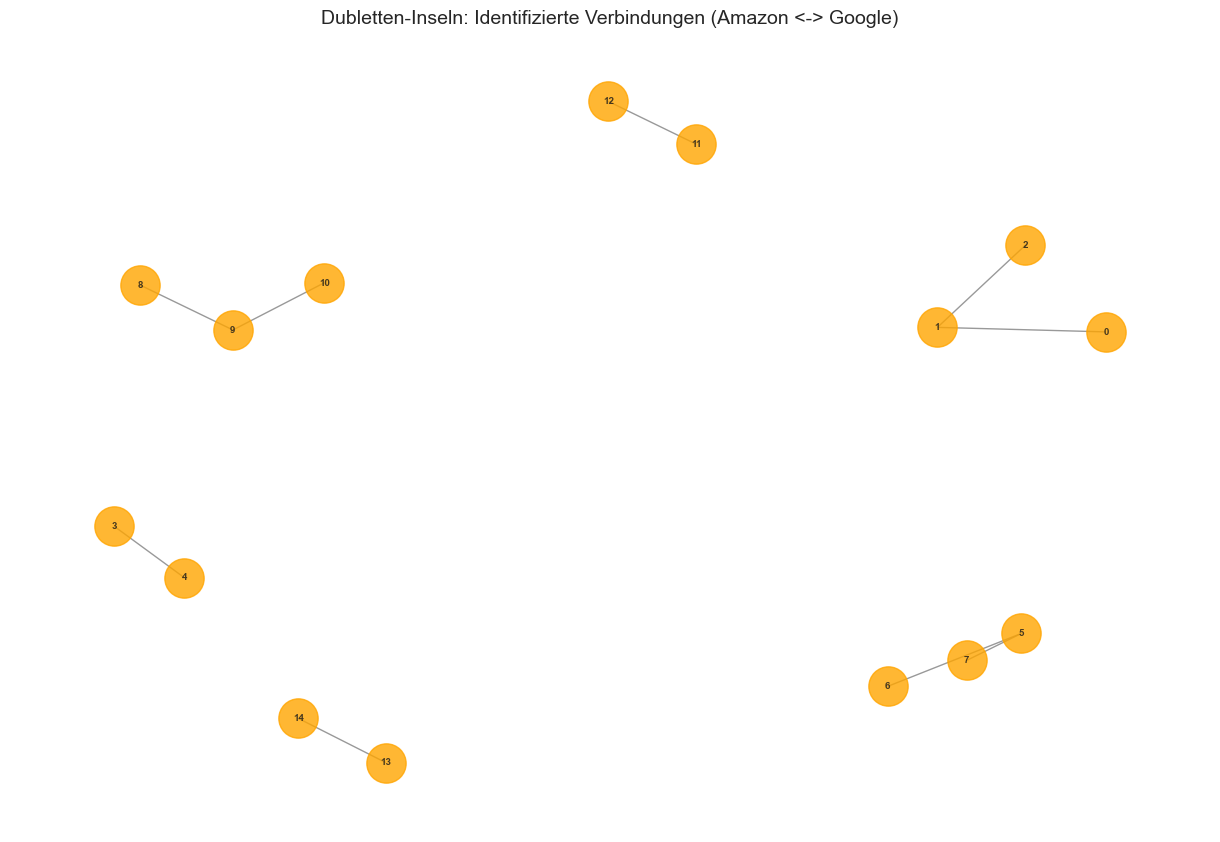

In [28]:
import matplotlib.pyplot as plt
import networkx as nx

probs_real = model_real.predict_proba(X_real)[:, 1]
final_preds_real = (probs_real >= thresh_real).astype(int)

confirmed_pairs_real = []

for idx, is_duplicate in enumerate(final_preds_real):
    if is_duplicate == 1:
        row_noisy, row_base = candidate_pairs_real[idx]
        
        id_google = f"google_{row_noisy.name}"
        id_amazon = f"amazon_{row_base.name}"
        
        confirmed_pairs_real.append((id_google, id_amazon))

print(f"{len(confirmed_pairs_real)} sichere Dubletten-Paare extrahiert.")

G_viz = nx.Graph()
G_viz.add_edges_from(confirmed_pairs_real)

subgraphs = [G_viz.subgraph(c).copy() for c in nx.connected_components(G_viz) if len(c) >= 2]

plt.figure(figsize=(12, 8))
combined_subgraph = nx.disjoint_union_all(subgraphs[:6]) if subgraphs else G_viz
pos = nx.spring_layout(combined_subgraph, k=0.5)

nx.draw(combined_subgraph, pos, with_labels=True, 
        node_color='orange', edge_color='gray', 
        node_size=800, font_size=7, font_weight='bold', alpha=0.8)

plt.title("Dubletten-Inseln: Identifizierte Verbindungen (Amazon <-> Google)", fontsize=14)
plt.show()

## Merging

In [29]:
df_amazon_labeled = df_amazon_clean.copy().rename(index=lambda x: f"amazon_{x}")
df_google_labeled = df_google_clean.copy().rename(index=lambda x: f"google_{x}")
df_all_labeled = pd.concat([df_amazon_labeled, df_google_labeled])

def build_golden_records(clusters, df_all):
    golden_records = []

    for cluster in clusters:
        members = df_all.loc[list(cluster)]

        members['is_base'] = members.index.str.startswith('base')

        best_record = members.sort_values(
            by=['is_base', 'text'],
            key=lambda x: x.str.len() if x.name == 'text' else x,
            ascending=False
        ).iloc[0]

        record_dict = best_record.to_dict()
        record_dict['cluster_size'] = len(cluster)
        record_dict['merged_ids'] = ", ".join(list(cluster))

        golden_records.append(record_dict)

    return pd.DataFrame(golden_records)

df_golden = build_golden_records(confirmed_pairs_real, df_all_labeled)

print(f"\n--- Finales Ergebnis ---")
print(f"Eingangsdaten Gesamt: {len(df_all_labeled)} Records")
print(f"Davon verschmolzen:    {len(confirmed_pairs_real)} Verbindungen")
print(f"Neue Golden Records:   {len(df_golden)} (Reduzierte Basis)")

if not df_golden.empty:
    print("\nBeispiel für einen Golden Record (Cluster > 1):")
    display(df_golden[df_golden['cluster_size'] > 1].head(3))


--- Finales Ergebnis ---
Eingangsdaten Gesamt: 4589 Records
Davon verschmolzen:    1146 Verbindungen
Neue Golden Records:   1146 (Reduzierte Basis)

Beispiel für einen Golden Record (Cluster > 1):


,text,id,ground_truth_id,is_base,cluster_size,merged_ids
0,learning quickbooks 2007 designed for new quic...,NaN,NaN,False,2,"google_0, amazon_b000hbxjxc"
1,quickbooks pointofsale basic 60 quickbooks poi...,NaN,NaN,False,2,"google_2, amazon_b000hbysc8"
2,adobe creative suite cs3 production premium up...,NaN,NaN,False,2,"google_4, amazon_b000ofnri8"


In [30]:
print("SHOWROOM: ERGEBNIS DER VERSCHMELZUNG")
print("-" * 50)

rich_clusters = df_golden[df_golden['cluster_size'] > 1]

if not rich_clusters.empty:
    sample_golden = rich_clusters.iloc[0] 
    
    original_ids = sample_golden['merged_ids']
    if isinstance(original_ids, str):
        original_ids = [x.strip() for x in original_ids.split(',')]

    print(f"GOLDEN RECORD (Verschmolzenes Ergebnis):")
    print(f"Text: {sample_golden['text'][:150]}...")
    print(f"Cluster-Größe: {sample_golden['cluster_size']}")
    
    print("\nURSPRUNGSDATEN (Die Quell-Systeme):")
    for o_id in original_ids:
        if o_id in df_all_labeled.index:
            orig_text = df_all_labeled.loc[o_id, 'text']
            source = "AMAZON" if "amazon" in o_id else "GOOGLE"
            print(f"[{source}]: {orig_text[:120]}...")
        else:
            print(f"ID {o_id} nicht in df_all_labeled gefunden.")
else:
    print("Keine Cluster mit mehreren Elementen gefunden.")

print("\n" + "="*80)

SHOWROOM: ERGEBNIS DER VERSCHMELZUNG
--------------------------------------------------
GOLDEN RECORD (Verschmolzenes Ergebnis):
Text: learning quickbooks 2007 designed for new quickbooks users running either quickbooks pro 2007 or quickbooks premier 2007 all versions learning quickbo...
Cluster-Größe: 2

URSPRUNGSDATEN (Die Quell-Systeme):
[GOOGLE]: learning quickbooks 2007 learning quickbooks 2007 intuit...
[AMAZON]: learning quickbooks 2007 designed for new quickbooks users running either quickbooks pro 2007 or quickbooks premier 2007...



In [24]:
print("HITL-QUARANTÄNE: MANUELLE PRÜFUNG ERFORDERLICH")
print("Wahrscheinlichkeit hoch (>70%), aber unter Sicherheits-Schwellenwert.")
print("-" * 50)

hitl_mask = (probs_real >= 0.70) & (probs_real < thresh_real)
hitl_indices = np.where(hitl_mask)[0]

hitl_data = []
for idx in hitl_indices:
    row_noisy, row_base = candidate_pairs_real[idx]
    confidence = probs_real[idx]
    
    hitl_data.append({
        'Confidence': confidence,
        'Google Snippet': row_noisy['text'][:100] + "...",
        'Amazon Record': row_base['text'][:100] + "...",
        'Action': 'NEEDS REVIEW'
    })

df_hitl = pd.DataFrame(hitl_data)

if not df_hitl.empty:
    df_hitl = df_hitl.sort_values(by='Confidence', ascending=False)
    
    display(df_hitl.style
            .format({'Confidence': '{:.2%}'})
            .background_gradient(subset=['Confidence'], cmap='YlOrRd')
            .set_caption("Liste der potenziellen Dubletten für Fachbereichs-Review"))
else:
    print("Glückwunsch! Keine unsicheren Kandidaten im gewählten Bereich gefunden.")

HITL-QUARANTÄNE: MANUELLE PRÜFUNG ERFORDERLICH
Wahrscheinlichkeit hoch (>70%), aber unter Sicherheits-Schwellenwert.
--------------------------------------------------


,Confidence,Google Snippet,Amazon Record,Action
2,86.90%,magix entertainment corp xtreme photostory on cd and dvd 6 ...,xtreme photostory on cd and dvd 6 magix entertainment...,NEEDS REVIEW
3,86.90%,magix entertainment corp xtreme photostory on cd and dvd 6 ...,xtreme photostory on cd and dvd 6 magix entertainment...,NEEDS REVIEW
0,86.25%,encore inc math advantage 2008 math advantage 2008 was specially developed to supplement classroom c...,math advantage 2008 math advantage 2008 was specially developed to supplement classroom curriculum b...,NEEDS REVIEW
16,86.25%,speak learn dutch the fast fun and easy way to learn dutch test your knowledge with quizzes and a c...,talk now learn dutch the fast fun and easy way to learn dutch test your knowledge with quizzes and a...,NEEDS REVIEW
10,82.02%,adobe after effects cs3 professional software for mac effects software after effects cs3 professiona...,adobe after effects cs3 bring your vision to life with blockbuster visual effects and compelling mot...,NEEDS REVIEW
9,82.02%,adobe after effects cs3 professional software for mac effects software after effects cs3 professiona...,adobe after effects cs3 bring your vision to life with blockbuster visual effects and compelling mot...,NEEDS REVIEW
1,81.48%,nova development corp ideasoft photo clip art 10000 stand out from the crowd with 10000 unique photo...,ideasoft photo clip art 10 000 stand out from the crowd with 10 000 unique photo images these bright...,NEEDS REVIEW
15,81.48%,individual software prmxw3 professor teaches excel word professor teaches excel word individual so...,professor teaches excel word professor teaches excel and word individual software...,NEEDS REVIEW
7,81.32%,adobe production premium cs3 software suite for windows professional editing software production pre...,adobe creative suite cs3 production premium maximize your productivity with adobe creative suite 3 p...,NEEDS REVIEW
8,81.32%,adobe production premium cs3 software suite for windows professional editing software production pre...,adobe creative suite cs3 production premium maximize your productivity with adobe creative suite 3 p...,NEEDS REVIEW


## Referenzen

Kusupati, A., Bhatt, G., Rege, A., Wallingford, M., Sinha, A., Ramanujan, V., … Farhadi, A. (2022). Matryoshka representation learning. Proceedings of the 36th International Conference on Neural Information Processing Systems. Presented at the New Orleans, LA, USA. Red Hook, NY, USA: Curran Associates Inc.

Günther, M., Sturua, S., Akram, M. K., Mohr, I., Ungureanu, A., Wang, B., … Xiao, H. (2025). jina-embeddings-v4: Universal Embeddings for Multimodal Multilingual Retrieval. arXiv [Cs.AI]. Retrieved from http://arxiv.org/abs/2506.18902